In [1]:
import os, copy, json
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
from os.path import join as opj

from cloth_fmri.config.config import CONFIG
from cloth_fmri.utils.svm import train_svm_classifier_xy, train_svm_classifier
from cloth_fmri.models.model_predictions import cnn_stiff_pred



def classify_file(fname):
    parts = fname.replace(".npy", "").split("_")
    return "scrambled" if len(parts) == 11 else "fmritest"


def remove_scramble_suffix(fname):
    parts = fname.replace(".npy", "").split("_")
    return "_".join(parts[:-2])


================ videomae ================
---------------- train intact / test intact
Test Accuracy: 0.8589
95% CI: [0.815, 0.899], mean=0.859, p= 0.000
---------------- train intact / test scrambled
Test Accuracy: 0.2560
95% CI: [0.218, 0.294], mean=0.256, p= 0.000

================ vivit ================
---------------- train intact / test intact
Test Accuracy: 0.9758
95% CI: [0.956, 0.992], mean=0.976, p= 0.000
---------------- train intact / test scrambled
Test Accuracy: 0.5766
95% CI: [0.532, 0.621], mean=0.577, p= 0.000

================ vjepa2_hf ================
---------------- train intact / test intact
Test Accuracy: 0.9879
95% CI: [0.972, 1.000], mean=0.988, p= 0.000
---------------- train intact / test scrambled
Test Accuracy: 0.5000
95% CI: [0.456, 0.544], mean=0.500, p= 0.000


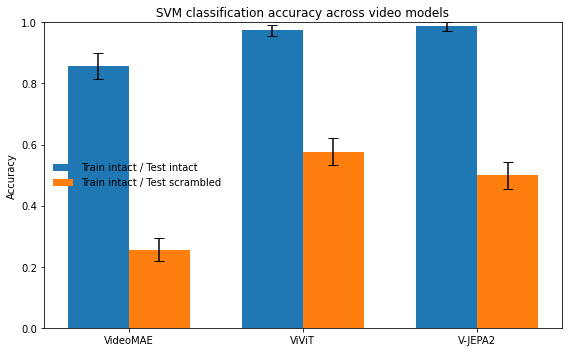

In [2]:
models = ["videomae", "vivit", "vjepa2_hf"]
model_labels = {
    "videomae": "VideoMAE",
    "vivit": "ViViT",
    "vjepa2_hf": "V-JEPA2",
}

n_boot = 10000

plot_rows = []
all_results = {}

for model_name in models:
    print(f"\n================ {model_name} ================")

    model_pred_dir = opj(
        CONFIG["data_root"],
        "baker_test/video_models/checkpoints",
        model_name
    )

    all_df = []

    for model_idx, (dirpath, _, filenames) in enumerate(os.walk(model_pred_dir)):
        target_file = "ridge_decoder_results.npz"

        if target_file not in filenames:
            continue

        npz_path = opj(dirpath, target_file)

        with np.load(npz_path, allow_pickle=True) as data:
            y_true = data["Y_test"][:, [0]].ravel()
            y_pred = data["test_pred"][:, [0]].ravel()
            raw_names = data["test_file_names"].ravel()

            file_names = [
                n.decode("utf-8", errors="ignore") if isinstance(n, (bytes, bytearray)) else str(n)
                for n in raw_names
            ]

            df = pd.DataFrame({
                "file_name": file_names,
                "y_true": y_true,
                "y_pred": y_pred,
                "model_idx": model_idx,
            })

            all_df.append(df)

    all_df = pd.concat(all_df, ignore_index=True) if all_df else pd.DataFrame()

    if all_df.empty:
        print(f"No data found for {model_name}")
        continue

    all_df["data_type"] = all_df["file_name"].apply(classify_file)

    # =========================================================
    # scrambled dataset
    # =========================================================
    scrambled_df = (
        all_df.query("data_type == 'scrambled'")
        .assign(file_name=lambda x: x["file_name"].apply(remove_scramble_suffix))
    )

    scrambled_df_mean = (
        scrambled_df
        .groupby(["file_name", "model_idx"], as_index=False)
        .agg(
            y_true=("y_true", "mean"),
            y_pred=("y_pred", "mean")
        )
    )

    # =========================================================
    # intact dataset
    # =========================================================
    fmritest_df = all_df.query("data_type == 'fmritest'")

    valid_files = scrambled_df_mean["file_name"].unique()

    fmritest_df = (
        fmritest_df
        .loc[fmritest_df["file_name"].isin(valid_files)]
    )

    # =========================================================
    # ensure ordering consistency
    # =========================================================
    scrambled_df_mean = scrambled_df_mean.sort_values(["model_idx", "file_name"])
    fmritest_df = fmritest_df.sort_values(["model_idx", "file_name"])

    # =========================================================
    # numpy arrays
    # =========================================================
    x_scramble = scrambled_df_mean["y_pred"].to_numpy()[:, None]
    y_scramble = scrambled_df_mean["y_true"].map(lambda x: f"{x:.3f}").to_numpy()

    x_intact = fmritest_df["y_pred"].to_numpy()[:, None]
    y_intact = fmritest_df["y_true"].map(lambda x: f"{x:.3f}").to_numpy()

    # =========================================================
    # classification
    # =========================================================
    print("---------------- train intact / test intact")
    res_train_intact_test_intact = train_svm_classifier(
        data_or_X=x_intact,
        y=y_intact,
        n_boot=n_boot,
        plot=False,
        save_fig=False,
    )

    print("---------------- train intact / test scrambled")
    res_train_intact_test_scramble = train_svm_classifier_xy(
        X_train=x_intact,
        X_test=x_scramble,
        y_train=y_intact,
        y_test=y_scramble,
        n_boot=n_boot,
        plot=False,
        save_fig=False,
    )

    all_results[model_name] = {
        "train_intact_test_intact": res_train_intact_test_intact,
        "train_intact_test_scramble": res_train_intact_test_scramble,
    }

    for condition, res in [
        ("Train intact / Test intact", res_train_intact_test_intact),
        ("Train intact / Test scrambled", res_train_intact_test_scramble),
    ]:
        ci_lower, ci_upper = res["ci"]

        plot_rows.append({
            "model": model_name,
            "model_label": model_labels.get(model_name, model_name),
            "condition": condition,
            "accuracy": res["accuracy"],
            "ci_lower": ci_lower,
            "ci_upper": ci_upper,
            "err_lower": res["accuracy"] - ci_lower,
            "err_upper": ci_upper - res["accuracy"],
        })


# =========================================================
# combined plot
# =========================================================
plot_df = pd.DataFrame(plot_rows)

condition_order = [
    "Train intact / Test intact",
    "Train intact / Test scrambled",
]

model_order = [m for m in models if m in plot_df["model"].values]
model_label_order = [model_labels.get(m, m) for m in model_order]

x = np.arange(len(model_order))
width = 0.35

plt.figure(figsize=(8, 5))

for i, condition in enumerate(condition_order):
    sub = (
        plot_df
        .query("condition == @condition")
        .set_index("model")
        .loc[model_order]
    )

    offset = (i - 0.5) * width

    plt.bar(
        x + offset,
        sub["accuracy"].values,
        width=width,
        yerr=[
            sub["err_lower"].values,
            sub["err_upper"].values,
        ],
        capsize=5,
        label=condition,
    )

plt.xticks(x, model_label_order)
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.title("SVM classification accuracy across video models")
plt.legend(frameon=False)
plt.tight_layout()

plt.show()

# This is the original DNN

----------------Original DNN + intact images ----------------
Test Accuracy: 1.0000
95% CI: [1.000, 1.000], mean=1.000, p= 0.000


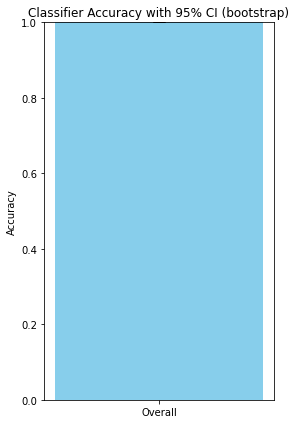

bootstrap mean = 1.0, ci=(1.0, 1.0)
 
----------------Original DNN + scramble images ----------------
Test Accuracy: 0.7016
95% CI: [0.645, 0.758], mean=0.702, p= 0.000


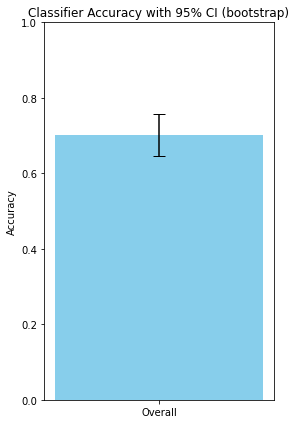

bootstrap mean = 0.7016129032258065, ci=(0.6451612903225806, 0.7580645161290323)


In [3]:
data = {}
for key in cnn_stiff_pred:
    split_key = key.split('_')
    data[f'{split_key[0]}_{split_key[-1]}'] = cnn_stiff_pred[key]
    
    
    
print(f'----------------Original DNN + intact images ----------------')
intact_data = copy.deepcopy(data)
result_intact = train_svm_classifier(data_or_X=intact_data, n_boot=n_boot, plot=True)
print(f'bootstrap mean = {result_intact["accuracy"]}, ci={result_intact["ci"]}')
print(' ')

print(f'----------------Original DNN + scramble images ----------------')
data_f = opj(CONFIG["data_root"], 'baker_test', 'dnn', 'original_dnn_on_scrambled_data.json')
with open(data_f, "r") as f:
    data = json.load(f)

scramble_data = copy.deepcopy(data)
result_scramble = train_svm_classifier(data_or_X=scramble_data, n_boot=n_boot, plot=True)
print(f'bootstrap mean = {result_scramble["accuracy"]}, ci={result_scramble["ci"]}')